In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.anova import AnovaRM
from statsmodels.formula.api import ols
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

In [16]:
df = pd.read_csv('/content/SalesData (Apr-24 - Mar-25).xlsx - Cleaned.csv')
df.head()

,Sale ID.,Date,Buyer Name,Buyer Type,Buyer Role,Buyer Description,Payment Method,Amount (₹),Unnamed: 8,Unnamed: 9,Buyer Type (HC),Payment Method (HC)
0,1,1-Apr-24,Unknown,Unregistered,Contractor,Carpenter/InteriorDesigner,CASH,271,NaN,NaN,Registered,CASH
1,2,1-Apr-24,Unknown,Unregistered,Contractor,Carpenter/InteriorDesigner,CASH,284,NaN,NaN,Registered,CASH
2,3,1-Apr-24,Unknown,Unregistered,Contractor,Carpenter/InteriorDesigner,CASH,319,NaN,NaN,Registered,CASH
3,4,1-Apr-24,Unknown,Unregistered,Contractor,Carpenter/InteriorDesigner,UPI,2475,NaN,NaN,Registered,UPI
4,5,1-Apr-24,Unknown,Unregistered,Contractor,Carpenter/InteriorDesigner,UPI,1500,NaN,NaN,Registered,UPI


In [4]:
df_ec = df[df['Buyer Role'] == 'End Customer'].copy()

In [5]:
import numpy as np

def subsegment_ec(df_ec, contractor_ratio=0.8):
    n_total = len(df_ec)
    n_contractor = int(n_total * contractor_ratio)

    # Randomly choose indices to mark as contractor-influenced
    contractor_indices = np.random.choice(df_ec.index, size=n_contractor, replace=False)

    df_ec['EC_Type'] = 'Organic'
    df_ec.loc[contractor_indices, 'EC_Type'] = 'Contractor-Influenced'

    return df_ec


In [6]:
df_ec_segmented = subsegment_ec(df_ec)

# Now you can compute AOV, Std, Count, etc.
print(df_ec_segmented.groupby('EC_Type')['Amount (₹)'].describe())


                       count        mean           std     min     25%  \
EC_Type                                                                  
Contractor-Influenced  400.0  16711.3075  11178.416127  5010.0  7975.0   
Organic                100.0  16554.3700  12216.343530  5100.0  6987.5   

                           50%      75%      max  
EC_Type                                           
Contractor-Influenced  12790.0  21625.0  49982.0  
Organic                11170.0  23625.0  49940.0  


In [8]:
# 1. Monte Carlo Simulation (generate multiple versions of EC segmentation)
n_simulations = 1000
simulation_results = []

for _ in range(n_simulations):
    df_ec_sim = df_ec.copy()
    n_total = len(df_ec_sim)
    n_contractor = int(n_total * 0.8)
    contractor_indices = np.random.choice(df_ec_sim.index, size=n_contractor, replace=False)
    df_ec_sim['EC_Type'] = 'Organic'
    df_ec_sim.loc[contractor_indices, 'EC_Type'] = 'Contractor-Influenced'

    group_stats = df_ec_sim.groupby('EC_Type')['Amount (₹)'].agg(['mean', 'std']).reset_index()
    simulation_results.append(group_stats)

# 2. Select a representative simulation sample (the first one)
df_ec_segmented = df_ec.copy()
contractor_indices = np.random.choice(df_ec_segmented.index, size=int(len(df_ec_segmented) * 0.8), replace=False)
df_ec_segmented['EC_Type'] = 'Organic'
df_ec_segmented.loc[contractor_indices, 'EC_Type'] = 'Contractor-Influenced'

In [9]:
# 3. Descriptive Stats
desc_stats = df_ec_segmented.groupby('EC_Type')['Amount (₹)'].describe()

In [10]:
# 4. Levene’s Test
contractor_data = df_ec_segmented[df_ec_segmented['EC_Type'] == 'Contractor-Influenced']['Amount (₹)']
organic_data = df_ec_segmented[df_ec_segmented['EC_Type'] == 'Organic']['Amount (₹)']
levene_result_ec = stats.levene(contractor_data, organic_data)

In [11]:
# 5. T-test
ttest_result_ec = stats.ttest_ind(contractor_data, organic_data, equal_var=False)

In [12]:
# 6. Visualizations
plt.figure(figsize=(18, 5))

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

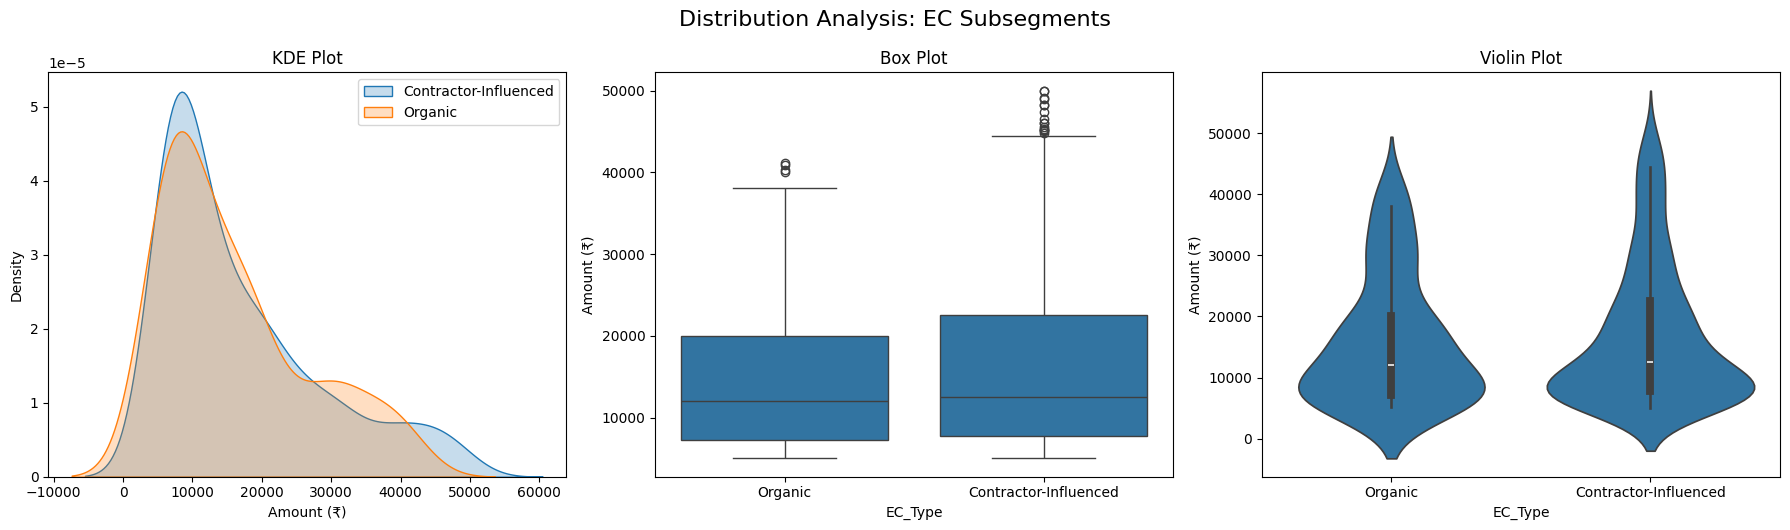

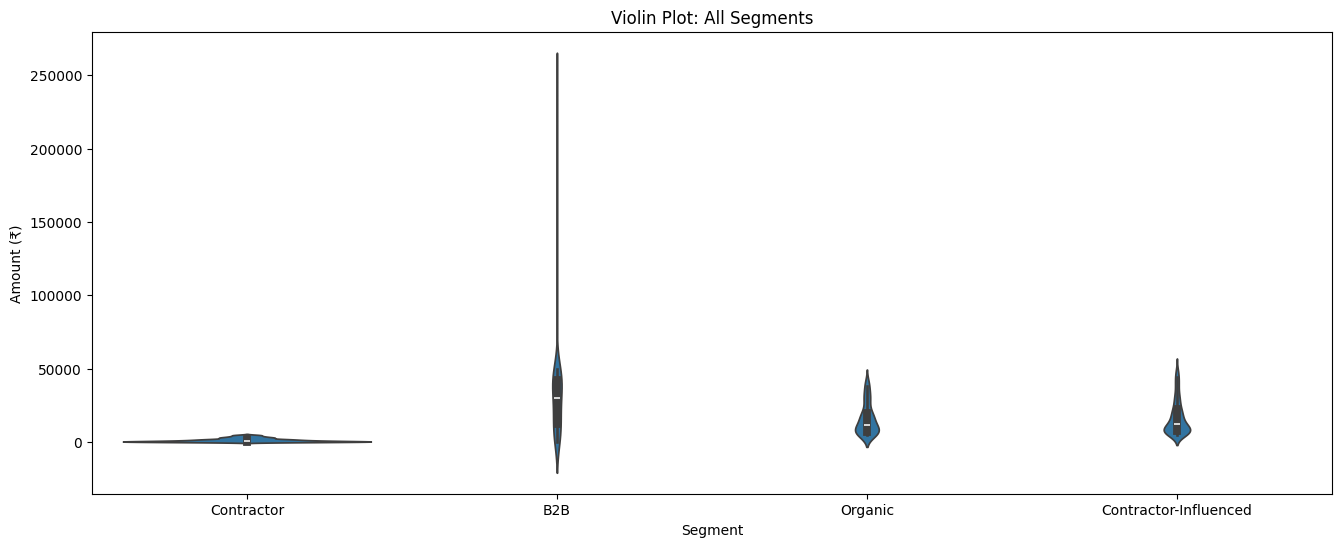

(LeveneResult(statistic=np.float64(0.35376790973746003), pvalue=np.float64(0.5522580568210946)),
 TtestResult(statistic=np.float64(0.7059208512002725), pvalue=np.float64(0.48123169067213745), df=np.float64(165.19541215835164)),
                        count        mean           std     min     25%  \
 EC_Type                                                                  
 Contractor-Influenced  400.0  16848.9725  11602.785125  5010.0  7800.0   
 Organic                100.0  16003.7100  10474.640923  5100.0  7195.0   
 
                            50%      75%      max  
 EC_Type                                           
 Contractor-Influenced  12500.0  22550.0  49982.0  
 Organic                12000.0  20000.0  41100.0  ,
 LeveneResult(statistic=np.float64(298.6583174457201), pvalue=np.float64(2.421765141900431e-159)),
                   sum_sq      df           F         PR(>F)
 C(Segment)  1.394231e+11     3.0  637.430674  3.448747e-288
 Residual    1.412245e+11  1937.0       

In [14]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.anova import AnovaRM
from statsmodels.formula.api import ols
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_csv('/content/SalesData (Apr-24 - Mar-25).xlsx - Cleaned.csv')

# Filter End Customer data
df_ec = df[df['Buyer Role'] == 'End Customer'].copy()

# 1. Monte Carlo Simulation (generate multiple versions of EC segmentation)
n_simulations = 1000
simulation_results = []

for _ in range(n_simulations):
    df_ec_sim = df_ec.copy()
    n_total = len(df_ec_sim)
    n_contractor = int(n_total * 0.8)
    contractor_indices = np.random.choice(df_ec_sim.index, size=n_contractor, replace=False)
    df_ec_sim['EC_Type'] = 'Organic'
    df_ec_sim.loc[contractor_indices, 'EC_Type'] = 'Contractor-Influenced'

    group_stats = df_ec_sim.groupby('EC_Type')['Amount (₹)'].agg(['mean', 'std']).reset_index()
    simulation_results.append(group_stats)

# 2. Select a representative simulation sample (the first one)
df_ec_segmented = df_ec.copy()
contractor_indices = np.random.choice(df_ec_segmented.index, size=int(len(df_ec_segmented) * 0.8), replace=False)
df_ec_segmented['EC_Type'] = 'Organic'
df_ec_segmented.loc[contractor_indices, 'EC_Type'] = 'Contractor-Influenced'

# 3. Descriptive Stats
desc_stats = df_ec_segmented.groupby('EC_Type')['Amount (₹)'].describe()

# 4. Levene’s Test
contractor_data = df_ec_segmented[df_ec_segmented['EC_Type'] == 'Contractor-Influenced']['Amount (₹)']
organic_data = df_ec_segmented[df_ec_segmented['EC_Type'] == 'Organic']['Amount (₹)']
levene_result_ec = stats.levene(contractor_data, organic_data)

# 5. T-test
ttest_result_ec = stats.ttest_ind(contractor_data, organic_data, equal_var=False)

# 6. Visualizations
plt.figure(figsize=(18, 5))

# KDE Plot
plt.subplot(1, 3, 1)
sns.kdeplot(data=contractor_data, label='Contractor-Influenced', fill=True)
sns.kdeplot(data=organic_data, label='Organic', fill=True)
plt.title('KDE Plot')
plt.legend()

# Box Plot
plt.subplot(1, 3, 2)
sns.boxplot(data=df_ec_segmented, x='EC_Type', y='Amount (₹)')
plt.title('Box Plot')

# Violin Plot
plt.subplot(1, 3, 3)
sns.violinplot(data=df_ec_segmented, x='EC_Type', y='Amount (₹)')
plt.title('Violin Plot')

plt.tight_layout()
plt.suptitle('Distribution Analysis: EC Subsegments', fontsize=16, y=1.05)
plt.show()

# 7. Add 'Segment' column to full dataset
df_full = df.copy()
df_full['Segment'] = df_full['Buyer Role']
df_full.loc[df_full['Buyer Role'] == 'End Customer', 'Segment'] = df_ec_segmented['EC_Type'].values

# 8. Levene’s Test for all 4 segments
segments = ['B2B', 'Contractor', 'Contractor-Influenced', 'Organic']
grouped_data = [df_full[df_full['Segment'] == seg]['Amount (₹)'] for seg in segments]
levene_result_all = stats.levene(*grouped_data)

# 9. ANOVA Test
df_anova = df_full[df_full['Segment'].isin(segments)]
anova_model = ols('Q("Amount (₹)") ~ C(Segment)', data=df_anova).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

# 10. Visualizations for All Segments
plt.figure(figsize=(16, 6))
sns.violinplot(data=df_anova, x='Segment', y='Amount (₹)')
plt.title('Violin Plot: All Segments')
plt.show()

levene_result_ec, ttest_result_ec, desc_stats, levene_result_all, anova_table


In [24]:
pip install pingouin


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 8.1 MB/s eta 0:00:00


In [25]:
import pingouin as pg

# Welch's ANOVA between EC subsegments
welch_result = pg.welch_anova(dv='Amount (₹)', between='EC_Type', data=df_ec_segmented)
print(welch_result)


    Source  ddof1       ddof2         F     p-unc       np2
0  EC_Type      1  165.195412  0.498324  0.481232  0.000884


In [26]:
welch_result_all = pg.welch_anova(dv='Amount (₹)', between='Segment', data=df_full)
print(welch_result_all)


    Source  ddof1       ddof2           F         p-unc       np2
0  Segment      3  225.470235  332.639202  1.717917e-82  0.496791


In [27]:
posthoc = pg.pairwise_gameshowell(dv='Amount (₹)', between='Segment', data=df_full)
print(posthoc)


                       A                      B       mean(A)       mean(B)  \
0                    B2B             Contractor  29160.104762   1461.550898   
1                    B2B  Contractor-Influenced  29160.104762  16848.972500   
2                    B2B                Organic  29160.104762  16003.710000   
3             Contractor  Contractor-Influenced   1461.550898  16848.972500   
4             Contractor                Organic   1461.550898  16003.710000   
5  Contractor-Influenced                Organic  16848.972500  16003.710000   

           diff           se          T          df          pval    hedges  
0  27698.553864  2609.091230  10.616169  104.039844  0.000000e+00  3.793262  
1  12311.132262  2672.567111   4.606482  114.467023  6.266157e-05  0.770487  
2  13156.394762  2811.269185   4.679877  136.507037  4.020853e-05  0.639876  
3 -15387.421602   581.261728 -26.472449  402.095163  1.882938e-13 -2.705528  
4 -14542.159102  1048.086192 -13.874965   99.235387  0.0